# Introduction
#### Project Objective:
This project analyzes Netflix's content data to understand how the platform has evolved its content strategy over time.

#### Key Focus:
We will explore trends in content production, regional distribution, and rating patterns to derive actionable insights for future growth.

In [1]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')# df--->variable where I store file # read_CSV---> read file and convert into DataFrame.
df.head() # shows first five rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info() # it shows summary of data(total rows and columns of data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.isnull().sum() #checks which rows are empty(0 --> non empty)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df['director'] = df['director'].fillna('unknown')# fill 'Unknown' in empty spaces in the row
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown',)

df.dropna(inplace=True) # delet full row if it has empty values
df.isnull().sum() # verify that data is clean now from missing values

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

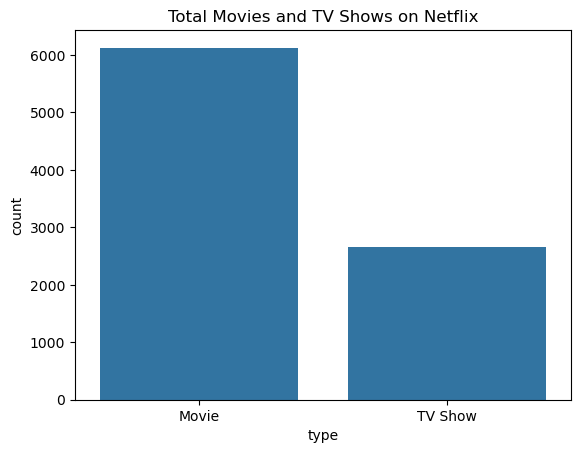

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='type',data=df)# countplot--> count catagories in 'type' column using 'df' data
plt.title('Total Movies and TV Shows on Netflix') # set the graph title
plt.show()# show graph      
# checking if netflix has more movies or TV shows

In [6]:
print(df.dtypes) # it shows the datatype of each column

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [7]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())#to_datetime--> func that convert columns into datetime format # str.strp-->remove extra spaces in dates
print(df[['date_added']].dtypes) # it change text to real date format

date_added    datetime64[ns]
dtype: object


In [8]:
df.duplicated().sum()# checks the duplicate rows

np.int64(0)

In [9]:
df['year_added'] = df['date_added'].dt.year# make new column for year that extract only year from data # dt-->datetime accessor of pandas

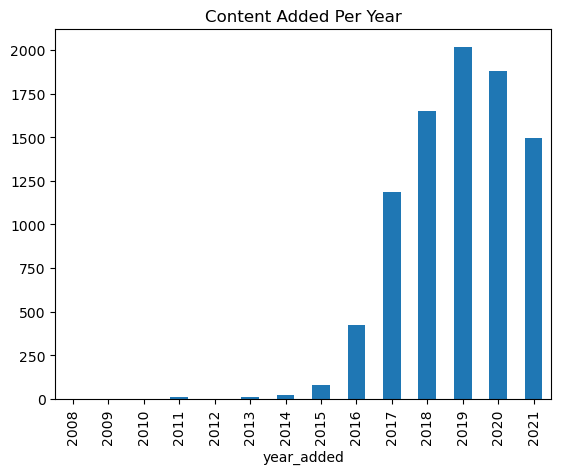

In [10]:
df['year_added'].value_counts().sort_index().plot(kind='bar')# value_count-->count values in year_added # sort_index-->show index(year column) in x-axis # kind'bar'--> kind of grapgh=bar graph
plt.title('Content Added Per Year')# gives title to the graph
plt.show()

#### Analysis of Content Added Per Year

Content releases were minimal until 2016, followed by a sharp, exponential growth that peaked in 2019, clearly indicating the platform's rapid global expansion phase.

In [11]:
df=df[df['country'] !='unknown']
df['country'].value_counts().head(10)# head(10)-->shows onlt top 10 countaries with highest count

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

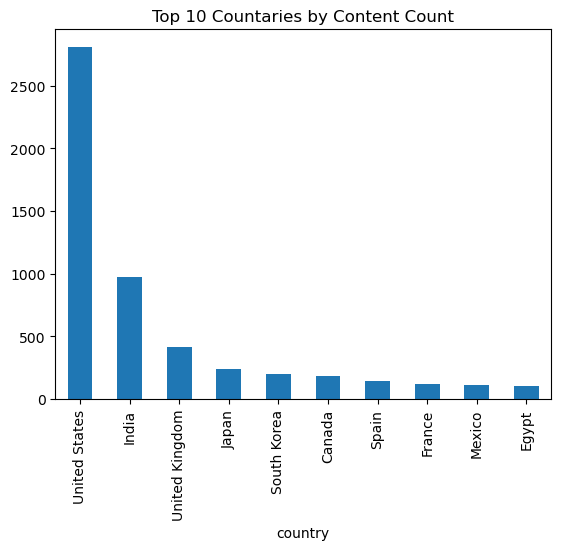

In [12]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countaries by Content Count')
plt.show()
# display the information in grapgh

#### Top 10 Countries by Content Production:

The United States is the leading producer of content, followed by India and the United Kingdom, which highlights the platform's focus on major global markets.

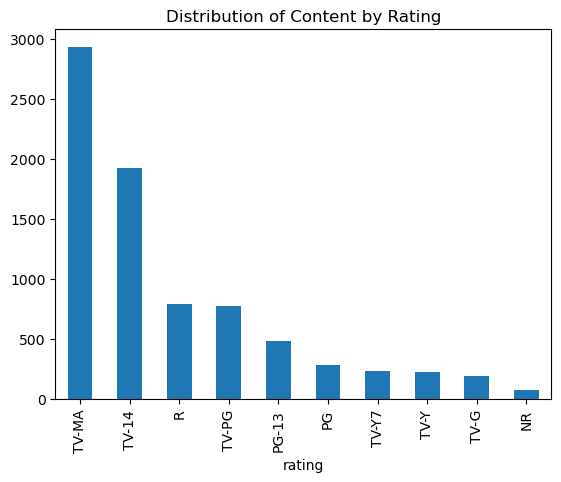

In [13]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Distribution of Content by Rating')
plt.show()

#### Distribution of Content by Rating:

The highest volume of content is rated TV-MA and TV-14, which indicates that the platform primarily caters to mature audiences and teenagers

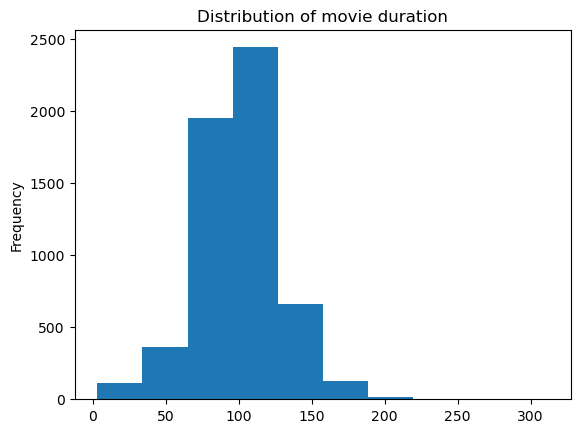

In [14]:
movies=df[df['type'] == 'Movie'].copy()# filter only movies from dataset
movies['duration']=movies['duration'].str.replace('min','').astype(int)#remove 'min' from duration and convert it to a number
movies['duration'].plot(kind='hist')# show grapgh of distribution of movie lengths
plt.title('Distribution of movie duration')
plt.show()

#### Distribution of Movie Duration:

Most movies fall in the 75-125 minute range, showing that the platform focuses on standard-length feature films for optimal viewer engagement.

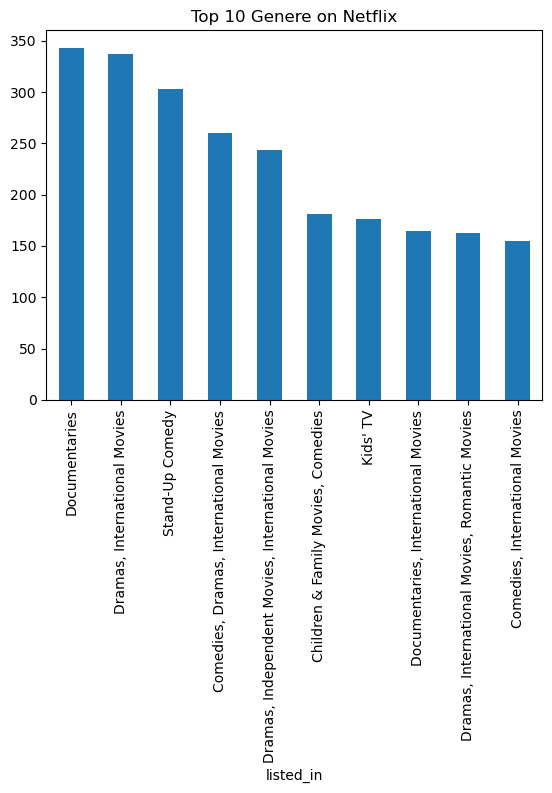

In [15]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genere on Netflix')
plt.show()

#### Top 10 Generes on the Platform:

Documentaries and International Movies are the most popular generes, indicating that viewers have a strong preference for non-fiction and diverse global content

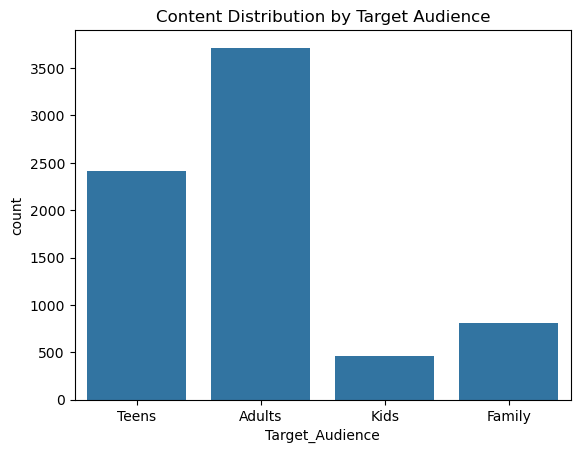

In [16]:
# Create a dictionary to map ratings to target audiences
audience_map = {
    'TV-MA':'Adults','R':'Adults','TV-14':'Teens','PG-13':'Teens','TV-PG':'Family','G':'Family','TV-Y':'Kids','TV-Y7':'Kids'
}

# Apply the mapping to create a new 'Target_Audience' column
df['Target_Audience']=df['rating'].map(audience_map)

#visualization
sns.countplot(x='Target_Audience',data=df)
plt.title('Content Distribution by Target Audience')
plt.show()

#### Target Audience Analysis

As seen in the chart, the majority of Netflix content is targeted toward Adults, indicating a niche focus on mature audiences.

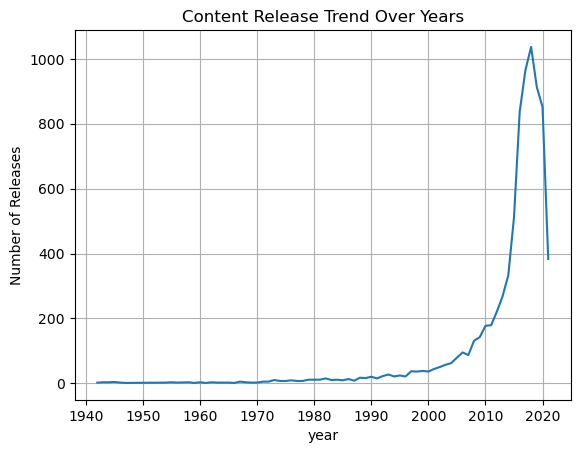

In [17]:
yearly_trend=df['release_year'].value_counts().sort_index()# Count releases per year and sort by year

yearly_trend.plot(kind='line')
plt.xlabel('year')
plt.ylabel('Number of Releases')
plt.title('Content Release Trend Over Years')
plt.grid(True)# displays grid lines on the graph
plt.show()

#### Yearly Content Analysis

The data shows a significant surge in content releases over the last decade, indicating Netflix's aggressive expansion strategy to capture the global market.

# Conclusion & Strategic Insights:


* The analysis reveals that content addition peaked between 2018-2020, suggesting a shift in Netflix’s growth strategy.

* USA leads in content production; however, Netflix should increase non-English content production to capture rising global market share.

* With a dominance of TV-MA ratings, there is a clear opportunity to diversify into family-oriented content to broaden the audience base.

# Recommendation & Future Scope

#### Future Scope:
To further improve this analysis, incorporating 'User Reviews' and 'Viewer Ratings' data would provide deeper insights.

#### Key Suggestions: 
Netflix should prioritize expanding 'Family-Oriented' content and increasing 'Non-English' content production to broaden its audience reach.
